In [20]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Link da tabela
SHEET_ID = "18CU_cT2nUkOGVovDUD6VRnpsdSrlNyrLZqCgt8nJFJs"

url_csv = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv"

# Lendo como CSV padrão
df = pd.read_csv(url_csv)

print("Colunas encontradas:", list(df.columns))
display(df.head())

Colunas encontradas: ['Nome', 'Dureza_Mohs', 'Brilho_Refrativo', 'Densidade_g_cm3', 'Era', 'Cor', 'Lapidacao', 'Corte', 'Porte_Fisico', 'Classe_Papel']


,Nome,Dureza_Mohs,Brilho_Refrativo,Densidade_g_cm3,Era,Cor,Lapidacao,Corte,Porte_Fisico,Classe_Papel
0,Garnet,9.0,1.76,3.98,1,Vermelho/Roxo,Facetado,Independente,Medio,Fusao_Guerreira
1,Ametista,7.0,1.54,2.65,1,Violeta,Hexagonal,Corte Rosa,Medio,Guerreira
2,Perola,3.5,1.55,2.71,1,Branco,Cabochao,Corte Rosa,Medio,Serva
3,Steven,7.0,1.54,2.65,3,Rosa,Pentagonal,Corte Rosa,Pequeno,Lider
4,Peridot,7.0,1.65,3.34,2,Verde,Triangular,Corte Amarela,Pequeno,Tecnica


In [21]:
# Atributos numéricos para o KNN e Árvore
FEATURES = ["Dureza_Mohs", "Brilho_Refrativo", "Densidade_g_cm3", "Era"]
TARGET = "Porte_Fisico"

# Garantindo que os dados sejam numéricos
for col in FEATURES:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Limpeza e padronização do alvo
df[TARGET] = df[TARGET].astype(str).str.strip().str.lower()
df = df.dropna(subset=FEATURES + [TARGET]).copy()

print(f"\nTotal de Gems para análise: {len(df)}")


Total de Gems para análise: 40


In [22]:
le = LabelEncoder()
y_all = le.fit_transform(df[TARGET])
X_all = df[FEATURES].values

print("Classes mapeadas:", list(le.classes_))

Classes mapeadas: ['grande', 'medio', 'pequeno']


In [23]:
RANDOM_STATE = 42
df_shuffled = df.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Define a porcentagem de teste (ex: 5%)
p_teste = 0.27
limite = int(len(df_shuffled) * p_teste)

test_df  = df_shuffled.iloc[:limite].copy()
train_df = df_shuffled.iloc[limite:].copy()

X_train = train_df[FEATURES].values
y_train = le.transform(train_df[TARGET])

X_test  = test_df[FEATURES].values
y_test  = le.transform(test_df[TARGET])

print(f"Treino: {len(X_train)} | Teste: {len(X_test)}")

Treino: 30 | Teste: 10


In [24]:
def dist_classes(frame, target_col, titulo):
    vc = frame[target_col].value_counts()
    pct = (vc / len(frame) * 100).round(1)
    out = pd.DataFrame({"Qtd": vc, "%": pct})
    print(f"\n--- {titulo} ---")
    display(out)

dist_classes(train_df, TARGET, "Distribuição no Treino")
dist_classes(test_df, TARGET, "Distribuição no Teste")



--- Distribuição no Treino ---


,Qtd,%
Porte_Fisico,,
medio,12,40.0
grande,10,33.3
pequeno,8,26.7



--- Distribuição no Teste ---


,Qtd,%
Porte_Fisico,,
grande,5,50.0
medio,3,30.0
pequeno,2,20.0


In [25]:
# Valor de K
K = 9
PESO = "distance"

model_knn = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=K, weights=PESO))
])

model_knn.fit(X_train, y_train)


Pipeline(steps=[('scaler', StandardScaler()),
                ('knn',
                 KNeighborsClassifier(n_neighbors=9, weights='distance'))])

In [26]:
y_pred = model_knn.predict(X_test)

print("Acurácia Final:", accuracy_score(y_test, y_pred))
print("\nRelatório de Métricas:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Acurácia Final: 0.5

Relatório de Métricas:
              precision    recall  f1-score   support

      grande       1.00      0.40      0.57         5
       medio       0.38      1.00      0.55         3
     pequeno       0.00      0.00      0.00         2

    accuracy                           0.50        10
   macro avg       0.46      0.47      0.37        10
weighted avg       0.61      0.50      0.45        10



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
test_df["Real"] = test_df[TARGET]
test_df["Previsto"] = le.inverse_transform(y_pred)

display(test_df[["Nome", "Real", "Previsto"] + FEATURES])

,Nome,Real,Previsto,Dureza_Mohs,Brilho_Refrativo,Densidade_g_cm3,Era
0,Holly Blue Agate,medio,medio,7.0,1.54,2.60,1
1,Topazio,grande,grande,8.0,1.61,3.53,1
2,Aquamarine,pequeno,medio,7.5,1.57,2.76,2
3,Sunstone,grande,medio,7.0,1.54,2.65,3
4,Peridot,pequeno,medio,7.0,1.65,3.34,2
5,Diamante Branco,grande,grande,10.0,2.42,3.52,1
6,Hessonite,medio,medio,7.0,1.74,3.65,1
7,Obsidian,grande,medio,7.0,1.48,2.40,3
8,Carnelian,medio,medio,7.0,1.54,2.61,1
9,Jasper,grande,medio,7.0,1.54,2.63,1


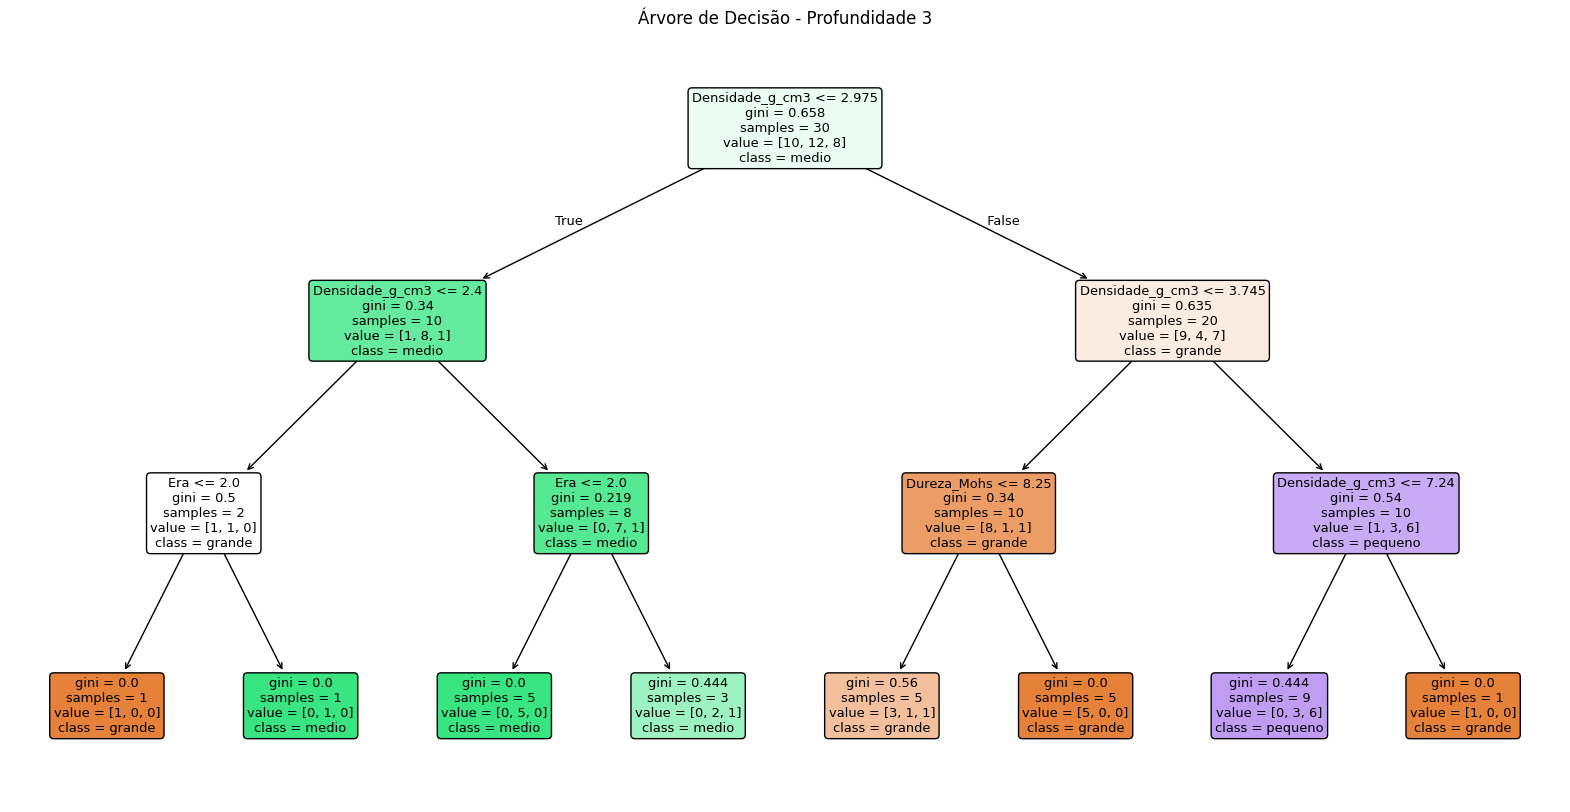

In [28]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

profundidade = 3

arvore = DecisionTreeClassifier(max_depth=profundidade, random_state=RANDOM_STATE)
arvore.fit(X_train, y_train)

plt.figure(figsize=(20,10))
plot_tree(arvore, feature_names=FEATURES, class_names=le.classes_, filled=True, rounded=True)
plt.title(f"Árvore de Decisão - Profundidade {profundidade}")
plt.show()